In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


In [4]:
df = pd.read_csv(r"E:\Durgesh 2025\project Recording\Coffee Shop Sales.csv")

# DATA OVERVIEW

In [5]:
df.head()

,Transaction_id,Transaction_date,Transaction_time,Transaction_qty,Store_id,Store_location,Product_id,Unit_price,Product_category,Product_name,Product_detail,Total Sales (Revenue),Year,Month Number,Month Name,Day of Week
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2023,1,Jan,Sunday
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023,1,Jan,Sunday
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2023,1,Jan,Sunday
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023,1,Jan,Sunday
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023,1,Jan,Sunday


In [6]:
df.shape

(149116, 16)

In [20]:
df['Hour'] = pd.to_datetime(df['Transaction_time'], format='%H:%M:%S').dt.hour

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Transaction_id         149116 non-null  int64  
 1   Transaction_date       149116 non-null  object 
 2   Transaction_time       149116 non-null  object 
 3   Transaction_qty        149116 non-null  int64  
 4   Store_id               149116 non-null  int64  
 5   Store_location         149116 non-null  object 
 6   Product_id             149116 non-null  int64  
 7   Unit_price             149116 non-null  float64
 8   Product_category       149116 non-null  object 
 9   Product_name           149116 non-null  object 
 10  Product_detail         149116 non-null  object 
 11  Total Sales (Revenue)  149116 non-null  float64
 12  Year                   149116 non-null  int64  
 13  Month Number           149116 non-null  int64  
 14  Month Name             149116 non-nu

In [9]:
df.describe()

,Transaction_id,Transaction_qty,Store_id,Product_id,Unit_price,Total Sales (Revenue),Year,Month Number
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.0,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219,4.686367,2023.0,3.988881
std,43153.600016,0.542509,2.074241,17.930020,2.658723,4.227099,0.0,1.673091
min,1.000000,1.000000,3.000000,1.000000,0.800000,0.800000,2023.0,1.000000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000,3.000000,2023.0,3.000000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000,3.750000,2023.0,4.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000,6.000000,2023.0,5.000000
max,149456.000000,8.000000,8.000000,87.000000,45.000000,360.000000,2023.0,6.000000


- Dataset contains 149K+ records

# Revenue by Product Category

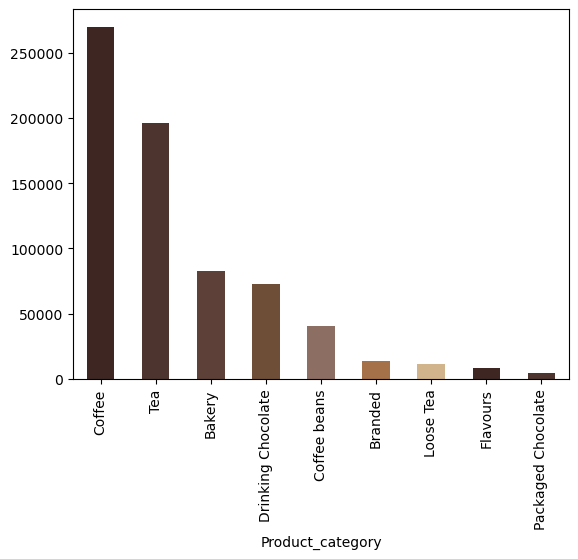

In [32]:
category_sales = df.groupby('Product_category')['Total Sales (Revenue)'].sum().sort_values(ascending=False)
coffee_palette = [
    '#3e2723', '#4e342e', '#5d4037',
    '#6f4e37', '#8d6e63', '#a47148',
    '#d2b48c'
]
category_sales.plot(kind='bar', color=coffee_palette[:len(category_sales)]
)
plt.show()


# Monthly Sales Trend

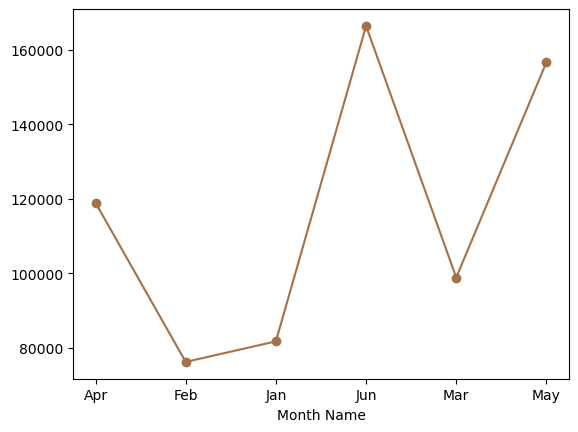

In [31]:
monthly_sales = df.groupby('Month Name')['Total Sales (Revenue)'].sum()

monthly_sales.plot(marker='o',color='#a47148' )
plt.show()
#Detects seasonal trends and performance fluctuations.

# Day-Wise Sales

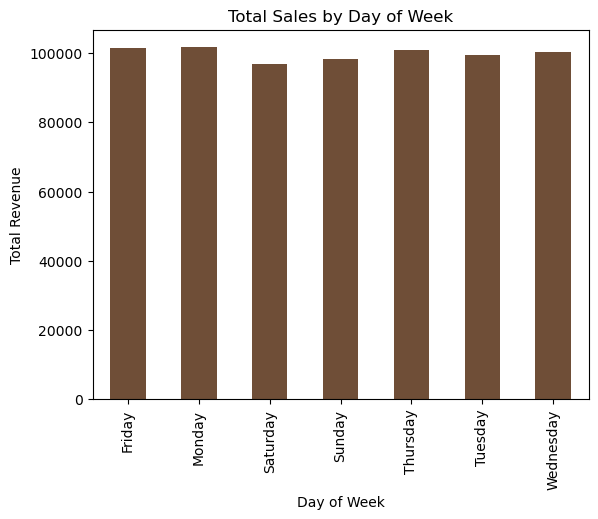

In [30]:
day_sales = df.groupby('Day of Week')['Total Sales (Revenue)'].sum()

day_sales.plot(kind='bar', color='#6f4e37')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.title('Total Sales by Day of Week')
plt.show()


# HOURLY SALES ANALYSIS

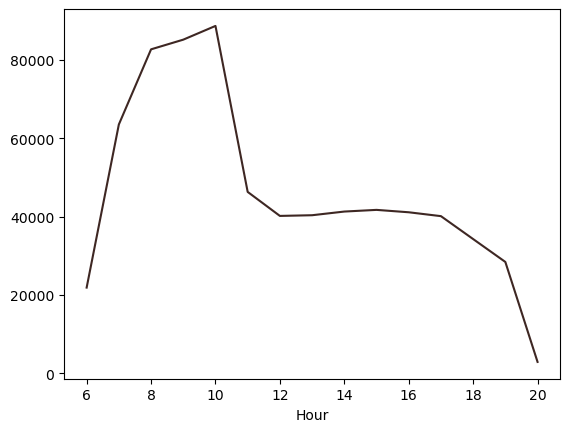

In [39]:
hourly_sales = df.groupby('Hour')['Total Sales (Revenue)'].sum()

hourly_sales.plot(color='#3e2723' )
plt.show()

# Compares category performance across months.

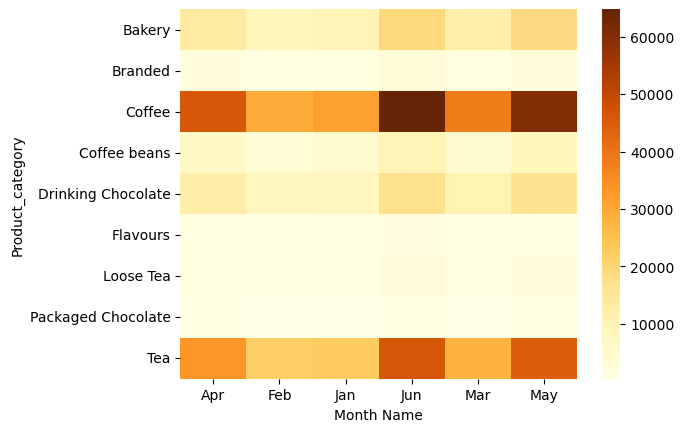

In [26]:
pivot = df.pivot_table(
    values='Total Sales (Revenue)',
    index='Product_category',
    columns='Month Name',
    aggfunc='sum'
)

sns.heatmap(pivot, cmap='YlOrBr')
plt.show()


# OUTLIER DETECTION

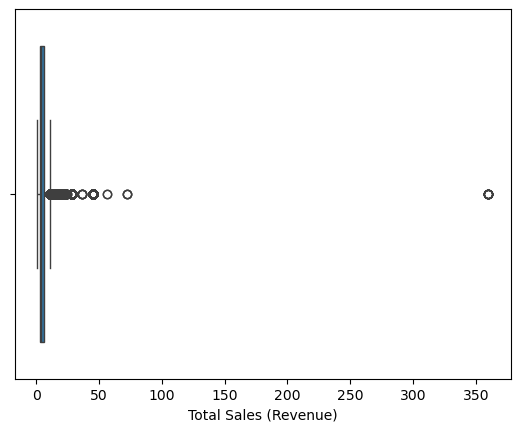

In [27]:
sns.boxplot(x=df['Total Sales (Revenue)'])
plt.show()

# CUSTOMER BEHAVIOR METRICS

In [28]:
df['Avg_Order_Value'] = df['Total Sales (Revenue)'] / df['Transaction_qty']
df['Avg_Order_Value'].describe()

# Helps understand pricing and purchase behavior.

count    149116.000000
mean          3.382219
std           2.658723
min           0.800000
25%           2.500000
50%           3.000000
75%           3.750000
max          45.000000
Name: Avg_Order_Value, dtype: float64

# PERCENTAGE CONTRIBUTION BY PRODUCT CATEGORY

In [40]:
# Calculate Percentage Contribution
# Convert Series to DataFrame
category_df = category_sales.reset_index()
category_df.columns = ['Product_category', 'Revenue']

# Percentage contribution
category_df['Revenue_Percentage'] = (
    category_df['Revenue'] / category_df['Revenue'].sum() * 100
).round(2)

category_df


,Product_category,Revenue,Revenue_Percentage
0,Coffee,269952.45,38.63
1,Tea,196405.95,28.11
2,Bakery,82315.64,11.78
3,Drinking Chocolate,72416.00,10.36
4,Coffee beans,40085.25,5.74
5,Branded,13607.00,1.95
6,Loose Tea,11213.60,1.60
7,Flavours,8408.80,1.20
8,Packaged Chocolate,4407.64,0.63


C:\Users\Dinesh\AppData\Local\Temp\ipykernel_9032\46975406.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_9032\46975406.py:13: UserWarning: 
The palette list has fewer values (7) than needed (9) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


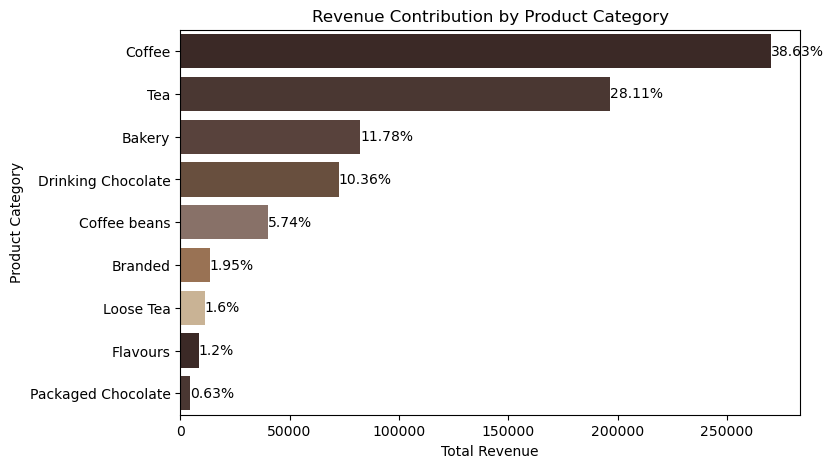

In [41]:
# Plot with Percentage Labels (Coffee Theme)
import seaborn as sns
import matplotlib.pyplot as plt

coffee_palette = [
    '#3e2723', '#4e342e', '#5d4037',
    '#6f4e37', '#8d6e63', '#a47148',
    '#d2b48c'
]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    y='Product_category',
    x='Revenue',
    data=category_df,
    palette=coffee_palette[:len(category_df)]
)

# Add percentage labels
for i, value in enumerate(category_df['Revenue_Percentage']):
    ax.text(
        category_df['Revenue'][i],
        i,
        f'{value}%',
        va='center'
    )

plt.title('Revenue Contribution by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.show()


In [44]:
df.to_csv("cleaned_coffee_sales.csv", index=False)
